<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/project_nathan/project_nathan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [1]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nathansawatzky","key":"703072937f56fc86b08c5c9e6f0bb134"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 741M/741M [00:40<00:00, 19.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4


In [5]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

print("Root:", path)
print("Level 1:", os.listdir(path))

for item in os.listdir(path):
    sub = os.path.join(path, item)
    if os.path.isdir(sub):
        print(f"\n{sub}:")
        print(os.listdir(sub)[:10])

Root: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4
Level 1: ['data', 'with_profile', 'with_profile_Jenny_1', 'with_profile_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/data:
['data']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile:
['with_profile']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile_Jenny_1:
['with_profile_Jenny_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/4/with_profile_1:
['with_profile_1']


In [8]:
dataset_path = os.path.join(path, "data", "data")
output_path = path + "/dataset_split"

valid_ext = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

# collect full dataset and labels
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    for f in os.listdir(label_path):
        if f.lower().endswith(valid_ext):
            full_path = os.path.join(label_path, f)
            image_paths.append(full_path)
            labels.append(label)

# Train/Test split -> random 42 to reporduce it
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# make function to copy paths into folders
def copy_to_split(paths, labels, split_name):
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(output_path, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)

        filename = os.path.basename(src_path)
        dest_path = os.path.join(dest_dir, filename)

        shutil.copy2(src_path, dest_path)

# copy into class folders
copy_to_split(train_paths, train_labels, "train")
copy_to_split(test_paths, test_labels, "test")

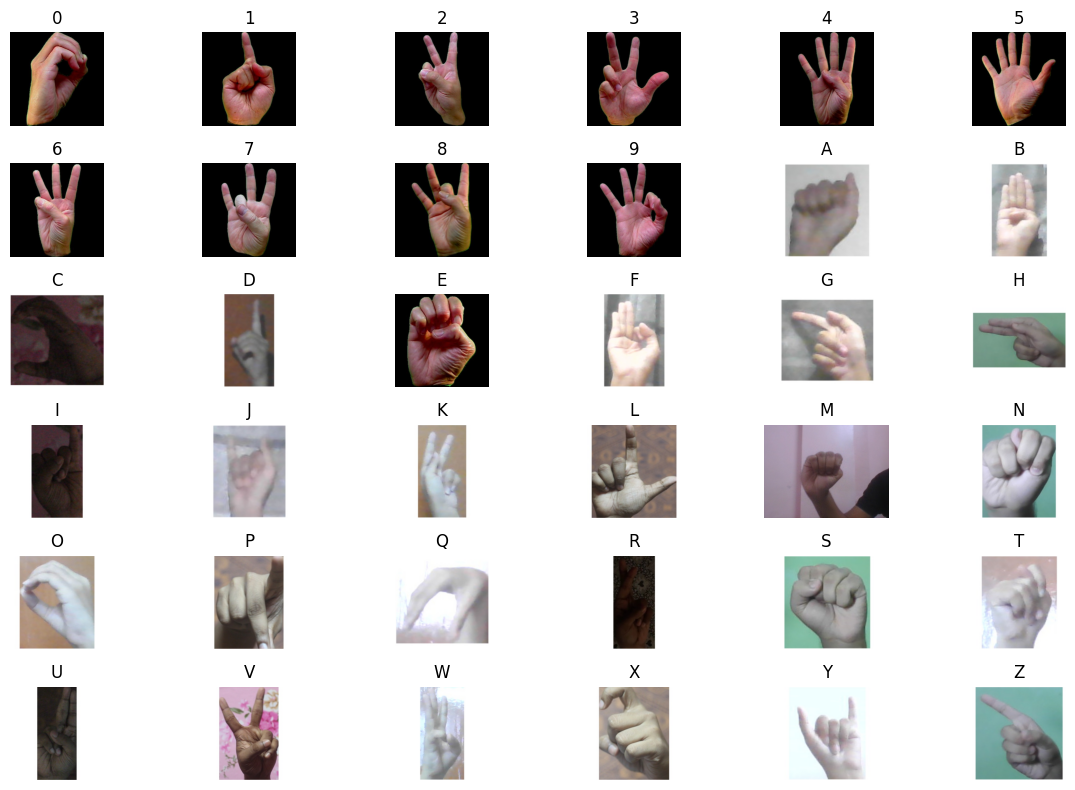

In [9]:
train_path = path + "/dataset_split/train"  # train path
labels = sorted(os.listdir(train_path))      # labels from folder names

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    label_path = os.path.join(train_path, label)

    if not os.path.isdir(label_path):
        continue

    # move images to class folder
    valid_ext = (".jpg", ".jpeg", ".png")
    images = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(valid_ext) and os.path.isfile(os.path.join(label_path, f))
    ]

    if len(images) == 0:
        continue

    # pick one random image per class
    img_name = random.choice(images)
    img_path = os.path.join(label_path, img_name)
    img = Image.open(img_path)

    plt.subplot(6, 6, i + 1)
    plt.imshow(img)
    plt.title(label.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

load the base of MobileNetV2

In [63]:
BaseModel = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(160, 160, 3),
    alpha=0.5
)

3201480/3201480 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Find what layers we should exit from:

In [64]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer_1
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_rel

The expabded relu is where we want to make the early exits, before it is projected

In [65]:
Exit1 = BaseModel.get_layer("block_6_expand_relu").output
Exit2 = BaseModel.get_layer("block_14_expand_relu").output

def ExitHead(x, NumClasses):
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  return layers.Dense(NumClasses, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, 10)
Exit2Output = ExitHead(Exit2, 10)


x = BaseModel.output
x = layers.GlobalAveragePooling2D()(x)
FinalOutput = layers.Dense(10, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])


In [71]:
num_classes = len(labels)
print(f"{num_classes} classes for training.")

def resize_images(image, label):
    image = tf.image.resize(image, [160, 160])
    return image, label




# redefine train_ds and test_ds using
# Set label_mode='categorical' for one-hot encoding as categorical_crossentropy is used
train_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)
train_ds = train_ds.map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)
test_ds  = test_ds.map(resize_images,  num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.map(lambda x, y: (x, (y, y, y))) #makes a training map that fits the early exit size
test_ds = test_ds.map(lambda x, y: (x, (y, y, y)))

for images, labels_one_hot in test_ds.take(1):
    break

36 classes for training.
Found 35260 files belonging to 36 classes.
Found 8815 files belonging to 36 classes.


In [72]:

# Redefine the ExitHead function and the model with the correct number of classes
Exit1 = BaseModel.get_layer("block_7_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

def ExitHead(x, num_classes_arg):
  x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  return layers.Dense(num_classes_arg, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, num_classes)
Exit2Output = ExitHead(Exit2, num_classes)

x = BaseModel.output
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
FinalOutput = layers.Dense(num_classes, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])

# Compile the model
NewModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=['categorical_crossentropy'] * 3,
    loss_weights = [0.5, 0.5, 1.0],
    metrics=['accuracy'] * 3) # Fixed: metrics should be a list of 3 for 3 outputs

# Fit the model
print("\nStarting model training...")
NewModel.fit(
    train_ds,
    validation_data = test_ds,
    epochs = 10,
)


Starting model training...
Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 213s 135ms/step - dense_76_accuracy: 0.2125 - dense_76_loss: 2.6948 - dense_78_accuracy: 0.3837 - dense_78_loss: 2.1735 - dense_80_accuracy: 0.7637 - dense_80_loss: 0.9836 - loss: 3.4179 - val_dense_76_accuracy: 0.2378 - val_dense_76_loss: 2.4606 - val_dense_78_accuracy: 0.5931 - val_dense_78_loss: 1.4927 - val_dense_80_accuracy: 0.8894 - val_dense_80_loss: 0.3866 - val_loss: 2.3642
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 85s 77ms/step - dense_76_accuracy: 0.3950 - dense_76_loss: 1.9949 - dense_78_accuracy: 0.7087 - dense_78_loss: 1.0213 - dense_80_accuracy: 0.9644 - dense_80_loss: 0.1661 - loss: 1.6743 - val_dense_76_accuracy: 0.4953 - val_dense_76_loss: 1.7323 - val_dense_78_accuracy: 0.7925 - val_dense_78_loss: 0.7368 - val_dense_80_accuracy: 0.9863 - val_dense_80_loss: 0.0503 - val_loss: 1.2836
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 138s 73ms/step - dense_76_accuracy: 0.5291 - dense_76_loss: 1.5513 - dense_7

In [73]:
tf.keras.models.save_model(NewModel, "/content/drive/MyDrive/Colab Notebooks/models/model_7_12lr1e4_smaller.keras")

In [74]:
#run if you want to load model
LoadedModel = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/models/model_7_12lr1e4_smaller.keras")

In [75]:
#run if you want to use newely trained model
LoadedModel = NewModel

In [76]:
results = LoadedModel.evaluate(test_ds, verbose=0)
metric_names = LoadedModel.metrics_names

# zip ensures matching length
df = pd.DataFrame(list(zip(metric_names, results)),
                  columns=["Metric", "Value"])

print(df.to_string(index=False))

         Metric    Value
           loss 0.167991
compile_metrics 0.288009
  dense_76_loss 0.031702
  dense_78_loss 0.008122
  dense_80_loss 0.919682


In [77]:
predictions = LoadedModel.predict(images)
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
exit_names = ["Exit 1 (early exit)", "Exit 2 (intermediate exit)", "Final Output"]

for i, pred in enumerate(predictions):
    y_pred = np.argmax(pred, axis=1)
    accuracy = np.mean(y_pred == true_labels)
    print(f"Overall accuracy for {exit_names[i]}: {accuracy*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Overall accuracy for Exit 1 (early exit): 87.50%
Overall accuracy for Exit 2 (intermediate exit): 96.88%
Overall accuracy for Final Output: 100.00%


In [87]:

import tempfile

def get_model_size(model):
    tmp_file = tempfile.NamedTemporaryFile(suffix=".keras", delete=False)
    model.save(tmp_file.name)

    size = os.path.getsize(tmp_file.name)
    return size / (1024**2)  # MB


FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])


print("Full model size (MB):", get_model_size(NewModel))
print("Final model size (MB):", get_model_size(FinalModel))

Full model size (MB): 32.62138748168945
Final model size (MB): 8.966540336608887


In [88]:
import time

def measure_inference_time(model, dataset, num_batches=50):
    times = []

    for i, (x, _) in enumerate(dataset.take(num_batches)):
        start = time.time()
        _ = model(x, training=False)
        end = time.time()

        batch_time = (end - start) / x.shape[0]  # per image
        times.append(batch_time)

    return np.mean(times) * 1000  # ms/image


In [91]:
FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])
print("Inference time:", measure_inference_time(FinalModel, test_ds))

Inference time: 6.3991788029670715


In [92]:
def predict_with_stats(model, dataset, threshold=0.9):
    exit_counts = {'exit_1': 0, 'exit_2': 0, 'exit_final': 0}
    total = 0

    for images, labels in dataset:
        exit1_pred, exit2_pred, final_pred = model.predict(images, verbose=0)

        for i in range(len(images)):
            total += 1
            if max(exit1_pred[i]) >= threshold:
                exit_counts['exit_1'] += 1
            elif max(exit2_pred[i]) >= threshold:
                exit_counts['exit_2'] += 1
            else:
                exit_counts['exit_final'] += 1

    # Print summary
    print(f"\nThreshold: {threshold}")
    print(f"Total samples: {total}")
    for exit_name, count in exit_counts.items():
        print(f"  {exit_name}: {count} ({count/total*100:.1f}%)")

    return exit_counts


exit_counts = predict_with_stats(NewModel, test_ds, threshold=0.9)


for t in [0.7, 0.8, 0.9, 0.95]:
    predict_with_stats(NewModel, test_ds, threshold=t)


Threshold: 0.9
Total samples: 8815
  exit_1: 5190 (58.9%)
  exit_2: 3259 (37.0%)
  exit_final: 366 (4.2%)

Threshold: 0.7
Total samples: 8815
  exit_1: 7003 (79.4%)
  exit_2: 1688 (19.1%)
  exit_final: 124 (1.4%)

Threshold: 0.8
Total samples: 8815
  exit_1: 6274 (71.2%)
  exit_2: 2330 (26.4%)
  exit_final: 211 (2.4%)

Threshold: 0.9
Total samples: 8815
  exit_1: 5190 (58.9%)
  exit_2: 3259 (37.0%)
  exit_final: 366 (4.2%)

Threshold: 0.95
Total samples: 8815
  exit_1: 4108 (46.6%)
  exit_2: 4112 (46.6%)
  exit_final: 595 (6.7%)


Output:0


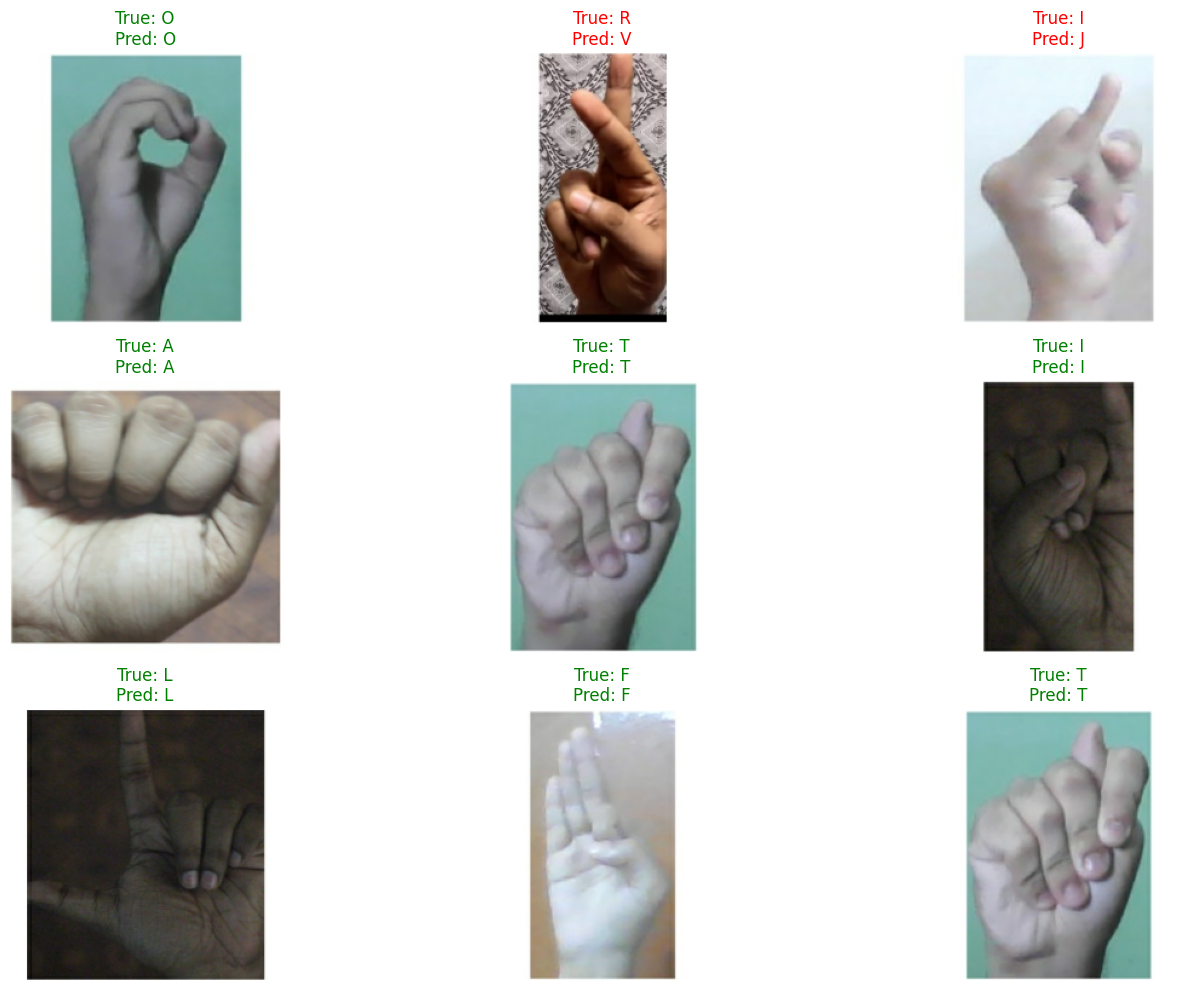

Output:1


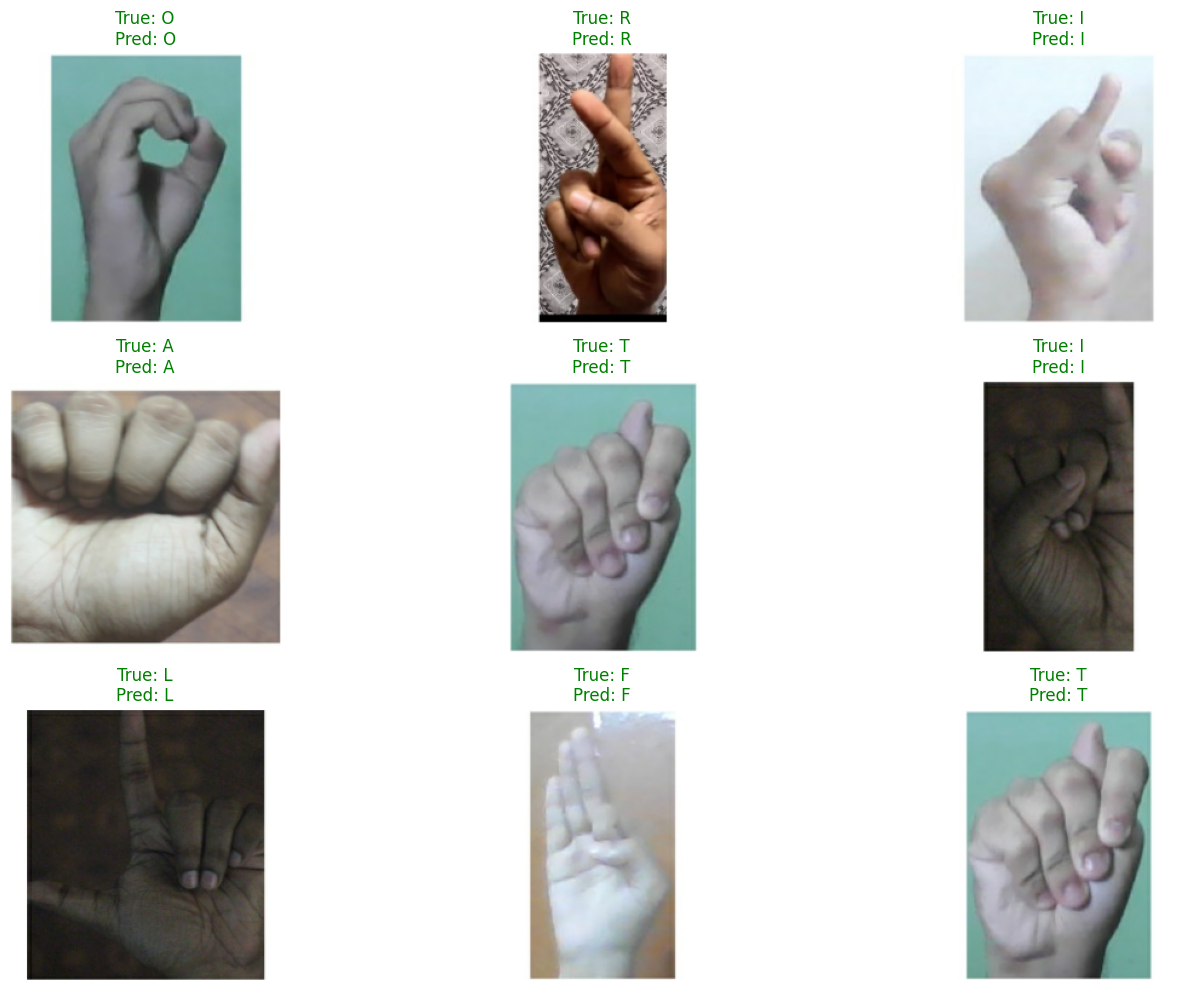

Output:2


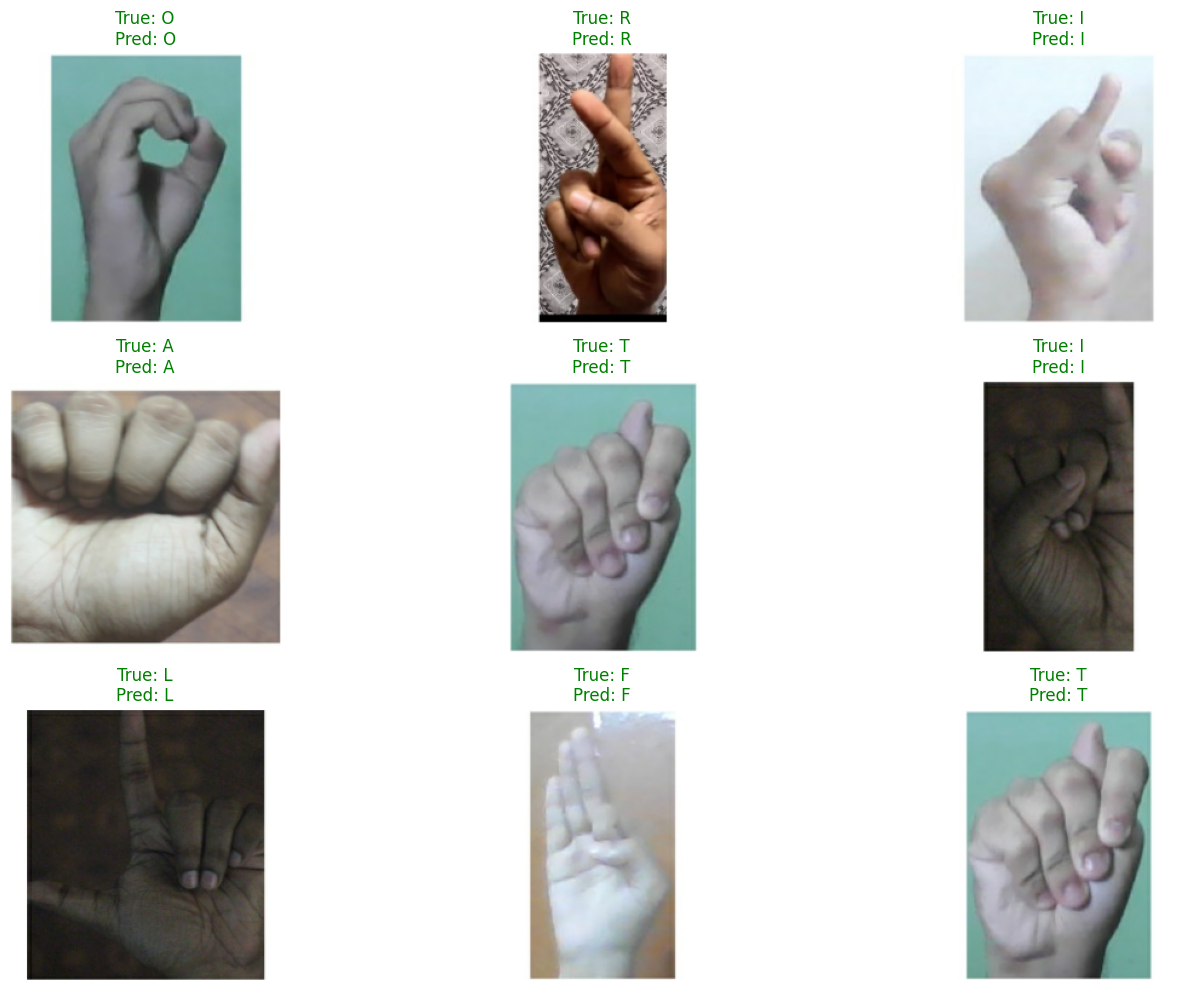

In [60]:
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
for j in range(3):
  print(f"Output:{j}")
  predicted_labels = tf.argmax(predictions[j], axis=1).numpy()

  plt.figure(figsize=(15, 10))
  for i in range(min(len(images), 9)):
      plt.subplot(3, 3, i + 1)
      plt.imshow(images[i].numpy().astype("uint8"))

      true_class_name = labels[true_labels[i]]
      predicted_class_name = labels[predicted_labels[i]]

      color = "green" if true_class_name == predicted_class_name else "red"
      plt.title(f"True: {true_class_name.upper()}\nPred: {predicted_class_name.upper()}", color=color)
      plt.axis("off")

  plt.tight_layout()
  plt.show()

In [61]:

y_pred0_list = []
y_pred1_list = []
y_pred2_list = []
y_trues_list = []
j=0

for x_batch, y_batch in test_ds:
  j+=1
  preds = LoadedModel.predict(x_batch, verbose=0)
  preds0_classes = np.argmax(preds[0], axis=1)
  preds1_classes = np.argmax(preds[1], axis=1)
  preds2_classes = np.argmax(preds[2], axis=1)
  y_trues_list.extend(tf.argmax(y_batch[0], axis=1).numpy())
  y_pred0_list.extend(preds0_classes)
  y_pred1_list.extend(preds1_classes)
  y_pred2_list.extend(preds2_classes)
  if j==10: #change depending on how many points in matrix you want
    break

y_preds = [np.array(y_pred0_list), np.array(y_pred1_list), np.array(y_pred2_list)]
y_true = np.array(y_trues_list)


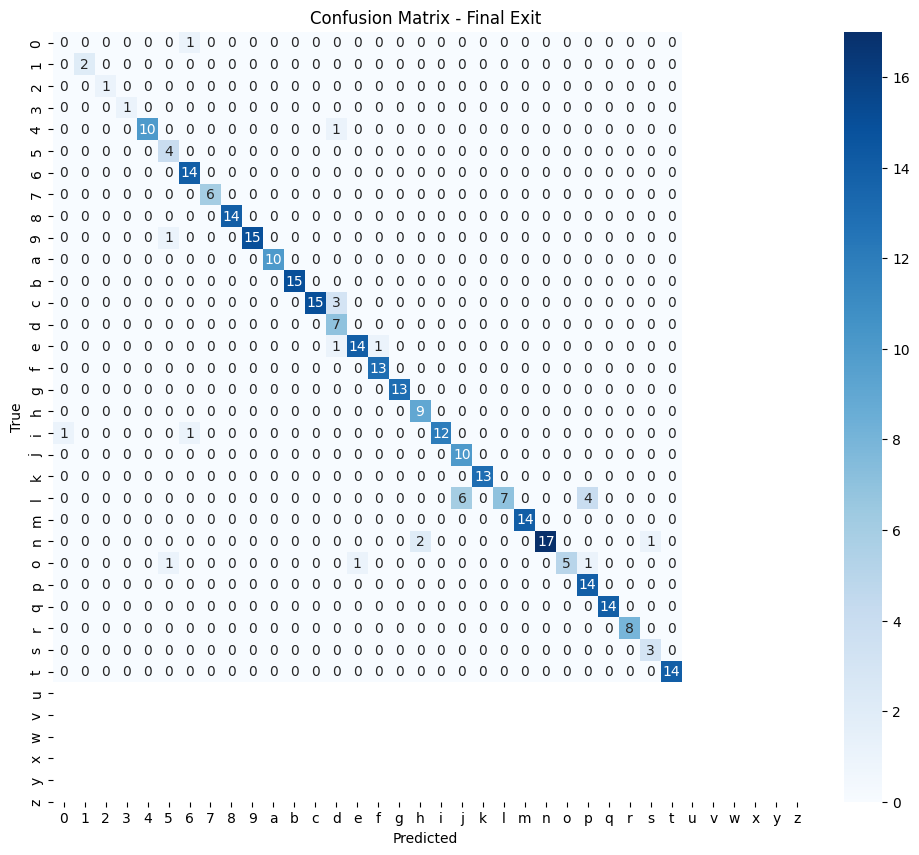

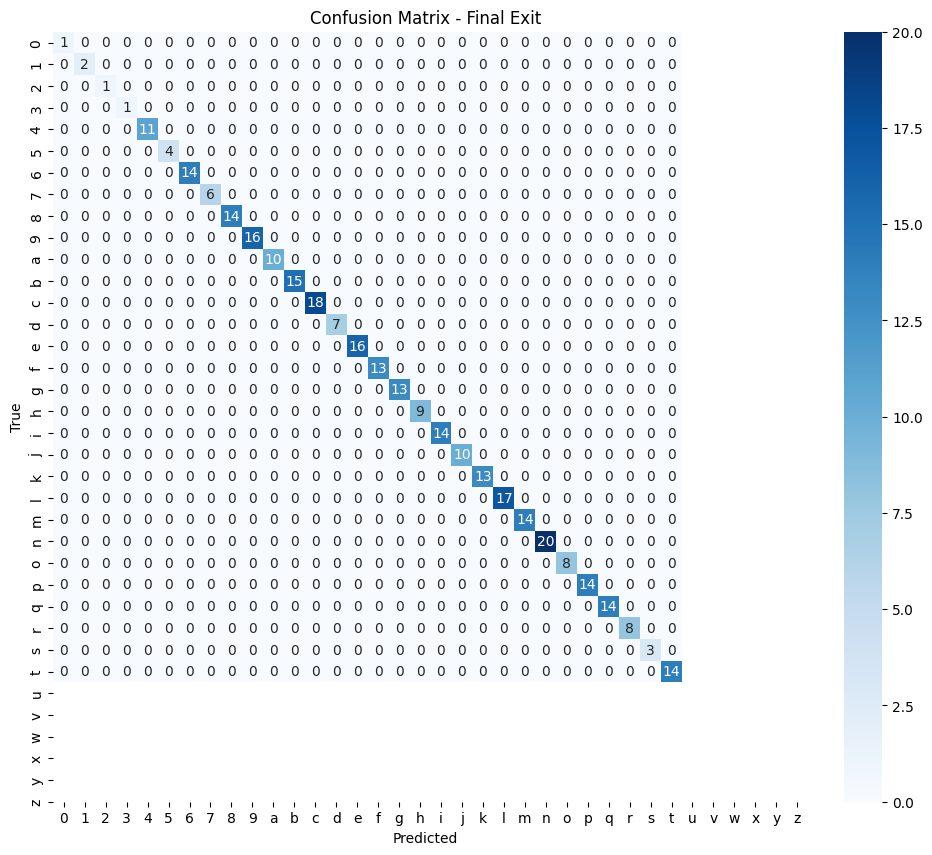

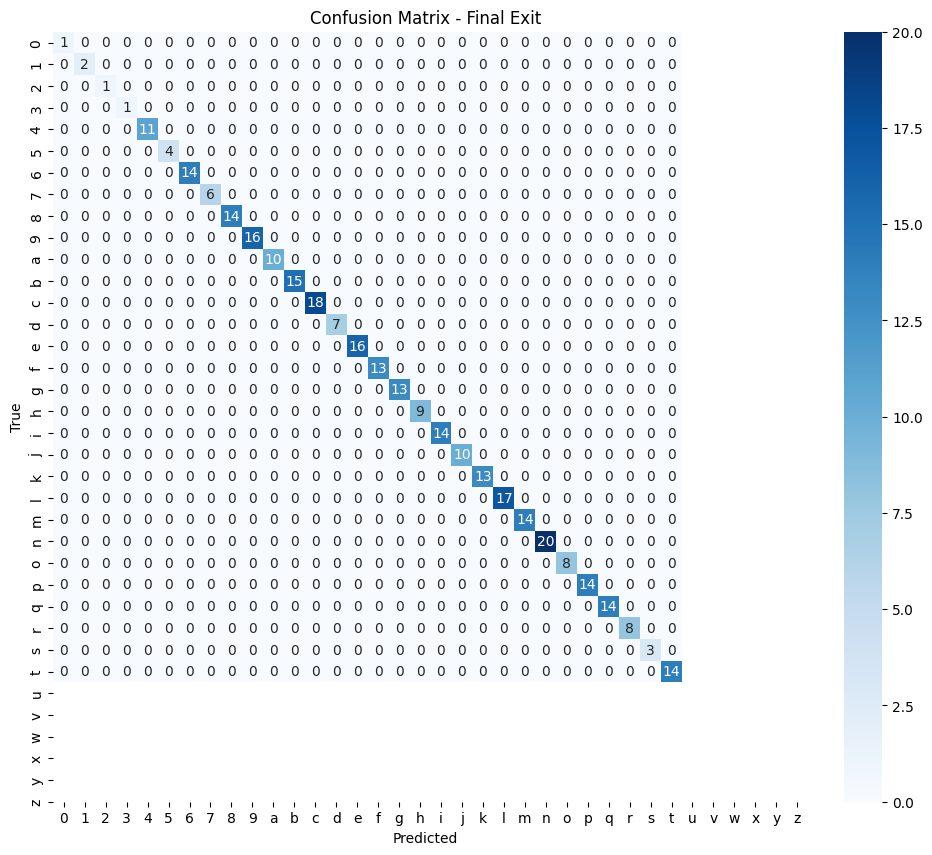

In [62]:

for y_pred in y_preds:
  cm = confusion_matrix(y_true, y_pred)
  class_labels = sorted(os.listdir(output_path + "/train"))

  plt.figure(figsize=(12,10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=class_labels,
              yticklabels=class_labels)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix - Final Exit")
  plt.show()